# 🛠️ Setting up the environment
- Install terratorch (restart the environment as prompted)
- Import the necessary python libraries


In [ ]:
!pip install terratorch

In [ ]:
import os
import torch
import random
import numpy as np
from PIL import Image

from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import albumentations as A
from albumentations.pytorch import ToTensorV2

from lightning.pytorch import Trainer
from terratorch.models import EncoderDecoderFactory
from terratorch.tasks import SemanticSegmentationTask
from terratorch.datamodules import GenericNonGeoSegmentationDataModule

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


# 📊 Import the dataset
## Dubai Aerial Semantic Segmentation Dataset
- Aerial LULC dataset;
- RBG bands;
- 6 LULC classes: *'Building', 'Unpaved Area', 'Road', 'Vegetation', 'Water', 'Unlabeled'*;
- Load the data ➡️ organize files in train/test directories for a training run.

In [ ]:
# Load the dataset from hugging_face: https://huggingface.co/datasets/harshinde/Aerial-Imagery

ds = load_dataset("harshinde/Aerial-Imagery")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/145 [00:00<?, ?it/s]

Tile 1/images/image_part_003.jpg:   0%|          | 0.00/146k [00:00<?, ?B/s]

Tile 1/images/image_part_007.jpg:   0%|          | 0.00/147k [00:00<?, ?B/s]

...

Tile 8/masks/image_part_006.png:   0%|          | 0.00/317k [00:00<?, ?B/s]

Tile 8/masks/image_part_008.png:   0%|          | 0.00/353k [00:00<?, ?B/s]

Tile 8/masks/image_part_007.png:   0%|          | 0.00/404k [00:00<?, ?B/s]

Tile 8/masks/image_part_009.png:   0%|          | 0.00/375k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/144 [00:00<?, ? examples/s]

In [ ]:
# Organize the training directories and split data into training and testing

base_dir = "/content/demo"

dirs = [
    f"{base_dir}/train/images",
    f"{base_dir}/train/labels",
    f"{base_dir}/test/images",
    f"{base_dir}/test/labels"
]

for d in dirs:
  os.makedirs(d, exist_ok=True)

tiles = list(range(72)) # The dataset is composed of 72 annotated images
random.seed(42)         # For consistency across runs

# Randomly splitting the 72 tiles into training and testing sets
random.shuffle(tiles)
split = int(0.8 * len(tiles))
train_tiles = set(tiles[:split])

### 🧹 Clean the dataset
Remap the classes in a consistent way and save them in the corresponding folders

In [ ]:
# Mapping the PIL RGB
MASTER_MAP = {
    (60, 16, 152):   0,   # Building (#3C1098)
    (132, 41, 246):  1,   # Unpaved Area (#8429F6)
    (110, 193, 228): 2,   # Road (#6EC1E4)
    (254, 221, 58):  3,   # Vegetation (#FEDD3A)
    (226, 169, 41):  4,   # Water (#E2A929)
    (155, 155, 155): 5,   # Unlabeled (#9B9B9B)
    (255, 255, 255): 5    # Unlabeled
}

# Helper function that converts the RGB PIL mask into a the remapped single-channel Image
def rgb_to_class_id(rgb_mask):
    """Converts an RGB PIL image to a single-channel Class ID array."""
    data = np.array(rgb_mask)
    h, w, _ = data.shape
    label_mask = np.zeros((h, w), dtype=np.uint8)

    # Remapping the masks into class_ids based on the RGB values
    for color, class_id in MASTER_MAP.items():
        matching = np.all(data == color, axis=-1)
        label_mask[matching] = class_id

    return Image.fromarray(label_mask, mode='L')

In [ ]:
# Save the images and corresponding masks to the correct directories renaming them appropriately
tile_id = 0

for i in range(0, len(ds['train']), 18):
  images = ds['train'][i:i+9]     # The loaded ds has a structure of alternating 9 images followed by 9 masks.
  masks  = ds['train'][i+9:i+18]

  for j in range(len(images['image'])):
    img = images['image'][j]
    mask_rgb = masks['image'][j].convert('RGB')
    mask = rgb_to_class_id(mask_rgb)

    subset = "train" if tile_id in train_tiles else "test"

    img.save(f"{base_dir}/{subset}/images/tile_{tile_id+1:03d}.png")
    mask.save(f"{base_dir}/{subset}/labels/tile_{tile_id+1:03d}.png")

    tile_id += 1

/tmp/ipykernel_14831/3693091714.py:24: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(label_mask, mode='L')


### 🗺️ Visualize an example from the dataset

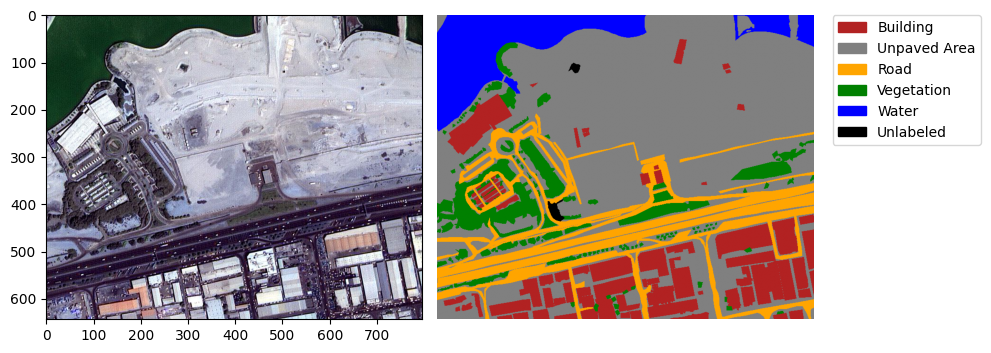

In [ ]:
# visualize example
from matplotlib.colors import ListedColormap
vis_img = Image.open("/content/demo/train/images/tile_008.png")
vis_mask = np.array(Image.open("/content/demo/train/labels/tile_008.png"))
classes = ["Building", "Unpaved Area", "Road", "Vegetation", "Water", "Unlabeled"]
colors = ["firebrick","gray","orange","green","blue","black"]
cmap = ListedColormap(colors)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(vis_img)
plt.subplot(1, 2, 2)
plt.imshow(vis_mask, cmap=cmap, vmin=0, vmax=5)
patches = [
    mpatches.Patch(color=cmap(i), label=classes[i])
    for i in range(6)
]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.axis("off")
plt.tight_layout()
plt.show()

# 📑 Set up the datamodule

Datamodules are python classes that get your ready to feed to a DL model. TerraTorch offers four Generic Datamodules (Segmentation, Regression, Classification, and Multimodal) and a number of Specific Datamodules for concrete datasets (such as Sen1Floods11, HLS_BurnScars, Landslide4Sense, and more).

To set up a GFM pipeline we need to clearly define a Datamodule for our data (this entails we know the structure and characteristics of our data very well).

In [ ]:
# First we need the statistics of our training data to perform standardization
from terratorch.utils import compute_statistics # TerraTorch provides a built in function to calculate the statistics

# Define a temporary datamodule
temp_dm = GenericNonGeoSegmentationDataModule(
    batch_size=4,
    num_workers=2,
    num_classes=6,
    train_data_root="/content/demo/train/images",
    train_label_data_root="/content/demo/train/labels",
    val_data_root="/content/demo/test/images",
    val_label_data_root="/content/demo/test/labels",
    test_data_root="/content/demo/test/images",
    test_label_data_root="/content/demo/test/labels"
)
temp_dm.setup("fit")

# Compute the statistics
stats = compute_statistics(temp_dm.train_dataloader())
means, stds = stats['means'], stats['stds']

Compute variance: 100%|██████████| 57/57 [00:02<00:00, 19.94it/s]


In [ ]:
stds

[75.08977582295124, 76.59657858929522, 80.89887355601404]

In [ ]:
# Define the datamodule with the transforms
datamodule = GenericNonGeoSegmentationDataModule(
    batch_size=4,
    num_workers=2,

    num_classes=6,

    train_data_root="/content/demo/train/images",
    train_label_data_root="/content/demo/train/labels",
    val_data_root="/content/demo/test/images",
    val_label_data_root="/content/demo/test/labels",
    test_data_root="/content/demo/test/images",
    test_label_data_root="/content/demo/test/labels",

    train_transform=A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),

        A.Resize(224, 224),
        A.Normalize(mean=means,
                    std=stds,
                    max_pixel_value=1.0),
        ToTensorV2(),
    ]),

    val_transform=A.Compose([
        A.Resize(224, 224),
        A.Normalize(mean=means,
                    std=stds,
                    max_pixel_value=1.0),
        ToTensorV2(),
    ]),

    test_transform=A.Compose([
        A.Resize(224, 224),
        A.Normalize(mean=means,
                    std=stds,
                    max_pixel_value=1.0),
        ToTensorV2(),
    ])
)

datamodule.setup("fit")

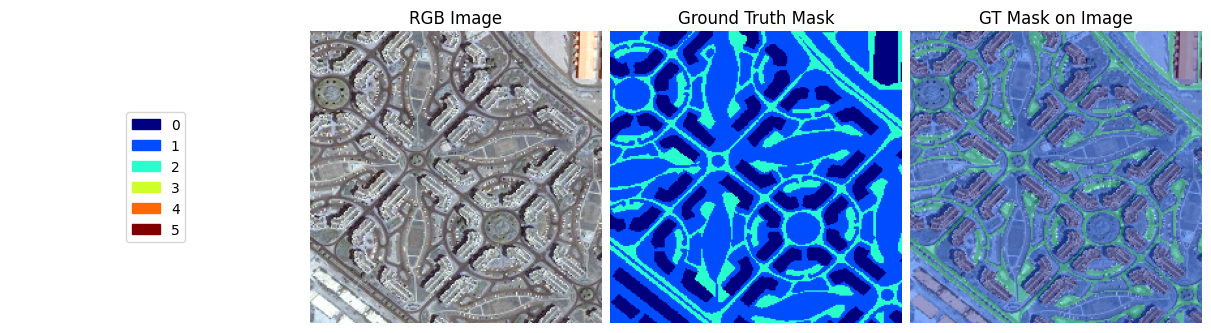

In [ ]:
# We can use the built in .plot() function of the datamodule to visualize the data:

train_dataset = datamodule.train_dataset
train_dataset.plot(train_dataset[5])
plt.show()

# ⚙️ Set up the model

In [ ]:
from terratorch.registry import TERRATORCH_BACKBONE_REGISTRY

# We can check in the Backbone registry what pretrained models we can use;
# In this example we will use one of the Prithvi backbones
# For a detailed overview of Prithvi check out a previous AI4Good Workshop: https://www.youtube.com/watch?v=CB3FKtmuPI8

[backbone
 for backbone in TERRATORCH_BACKBONE_REGISTRY
 if ('prithvi') in backbone]

['prithvi_eo_tiny',
 'prithvi_eo_v1_100',
 'prithvi_eo_v2_tiny_tl',
 'prithvi_eo_v2_100_tl',
 'prithvi_eo_v2_300',
 'prithvi_eo_v2_600',
 'prithvi_eo_v2_300_tl',
 'prithvi_eo_v2_600_tl']

In [ ]:
# Set up the Backbone, Neck, Decoder parameters:
model_args = dict(
    # Backbone setup: pretrained Prithvi using the RGB bands
    backbone="prithvi_eo_v2_300",
    backbone_pretrained=True,   # Load the pretrained weights
    backbone_num_frames=1,
    backbone_bands=["BLUE", "GREEN", "RED"],

    # Decoder setup:
    decoder="UNetDecoder",
    decoder_channels = [512, 256, 128, 64],

    # Neck setup:
    necks=[{"name": "SelectIndices", "indices": [5, 11, 17, 23]},
           {"name": "ReshapeTokensToImage"},
           {"name": "LearnedInterpolateToPyramidal"}],

    num_classes=6,
    head_dropout=0.1
)

In [ ]:
# Define the TerraTorch task using the model arguments:
task = SemanticSegmentationTask(
    model_args,
    "EncoderDecoderFactory",
    loss="ce",
    lr=1e-4,
    ignore_index=-1,
    optimizer="AdamW",
    optimizer_hparams={"weight_decay": 0.05},
    freeze_backbone = False,
    freeze_decoder = False,
    plot_on_val = False,
    class_names = ["Building", "Unpaved Area", "Road", "Vegetation", "Water", "Unlabeled"],
)

Prithvi_EO_V2_300M.pt:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

In [ ]:
# Define the Lightning trainer:
trainer = Trainer(accelerator="cuda",
                  max_epochs=5,       # For demo purposes just 5 epochs
                  devices=1,
                  precision='16-mixed',
                  default_root_dir="/content/demo/" # Where the experiments' outputs will be
                  )

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


# 🧠 Fine-tune the model

In [ ]:
# With everything set up, the training is run calling this one line of code:

trainer.fit(model=task, datamodule=datamodule)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │  323 M │ train │     0 │
│ 1 │ criterion     │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 323 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 323 M                                                                                                
Total estimated model params size (MB): 1.3 K                                                                      
Modules in train mode: 647                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric MulticlassAccuracy was called before the ``update`` method which may lead to errors, as metric states have 
not yet been updated.
  warnings.warn(*args, **kwargs)

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches 
(14) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if
you want to see logs for the training epoch.

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric MulticlassAccuracy was called before the ``update`` method which may lead to errors, as metric states have 
not yet been updated.
  warnings.warn(*args, **kwargs)

INFO: `Trainer.fit` stopped: `max_epochs=5` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


# ✅ Test the fine-tuned model

In [ ]:
best_ckpt_path = "/content/demo/lightning_logs/version_1/checkpoints/epoch=4-step=70.ckpt" # Load the checkpoint
trainer.test(model=task, datamodule=datamodule, ckpt_path=best_ckpt_path)

INFO: Restoring states from the checkpoint path at /content/demo/lightning_logs/version_1/checkpoints/epoch=4-step=70.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/demo/lightning_logs/version_1/checkpoints/epoch=4-step=70.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /content/demo/lightning_logs/version_1/checkpoints/epoch=4-step=70.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/demo/lightning_logs/version_1/checkpoints/epoch=4-step=70.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃           Test metric            ┃           DataLoader 0           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          test/Accuracy           │       0.45238372683525085        │
│        test/Boundary_mIoU        │       0.09631836414337158        │
│   test/Class_Accuracy_Building   │        0.5233628153800964        │
│     test/Class_Accuracy_Road     │        0.1682286113500595        │
│  test/Class_Accuracy_Unlabeled   │               0.0                │
│ test/Class_Accuracy_Unpaved Area │        0.7099708914756775        │
│  test/Class_Accuracy_Vegetation  │        0.7568127512931824        │
│    test/Class_Accuracy_Water     │        0.5559272766113281        │
│          test/F1_Score           │       0.41239064931869507        │
│        test/IoU_Building         │       0.34452369809150696        │
│          test/IoU_Road           │       0.13953758776187897        │
│        test/IoU_Unlabeled        │               0.0                │
│      test/IoU_Unpaved Area       │        0.6182836890220642        │
│       test/IoU_Vegetation        │       0.14964255690574646        │
│          test/IoU_Water          │        0.5296435952186584        │
│       test/Pixel_Accuracy        │        0.5801073312759399        │
│            test/loss             │        1.2339690923690796        │
│            test/mIoU             │       0.29693853855133057        │
│         test/mIoU_Micro          │        0.4085572063922882        │
└──────────────────────────────────┴──────────────────────────────────┘

[{'test/loss': 1.2339690923690796,
  'test/Accuracy': 0.45238372683525085,
  'test/Boundary_mIoU': 0.09631836414337158,
  'test/Class_Accuracy_Building': 0.5233628153800964,
  'test/Class_Accuracy_Unpaved Area': 0.7099708914756775,
  'test/Class_Accuracy_Road': 0.1682286113500595,
  'test/Class_Accuracy_Vegetation': 0.7568127512931824,
  'test/Class_Accuracy_Water': 0.5559272766113281,
  'test/Class_Accuracy_Unlabeled': 0.0,
  'test/F1_Score': 0.41239064931869507,
  'test/IoU_Building': 0.34452369809150696,
  'test/IoU_Unpaved Area': 0.6182836890220642,
  'test/IoU_Road': 0.13953758776187897,
  'test/IoU_Vegetation': 0.14964255690574646,
  'test/IoU_Water': 0.5296435952186584,
  'test/IoU_Unlabeled': 0.0,
  'test/Pixel_Accuracy': 0.5801073312759399,
  'test/mIoU': 0.29693853855133057,
  'test/mIoU_Micro': 0.4085572063922882}]

## 🖼️ Visualize the predictions

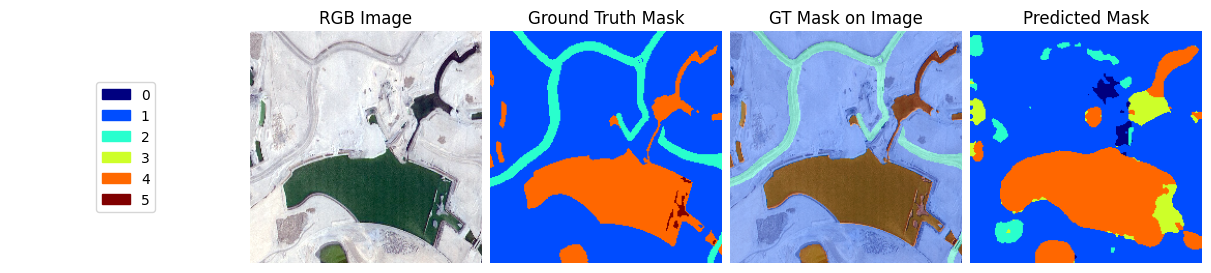

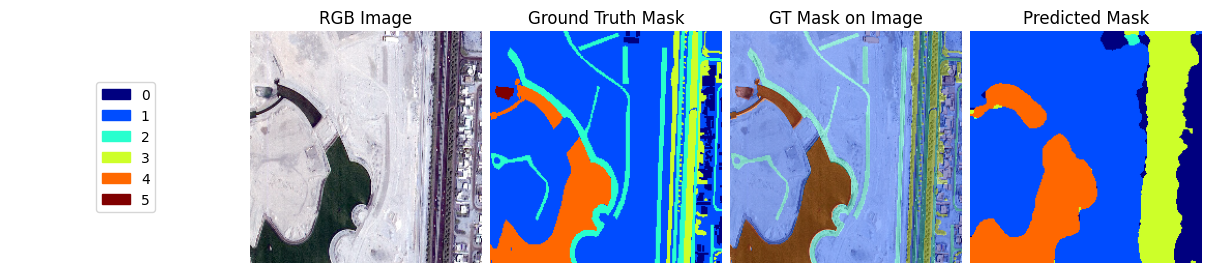

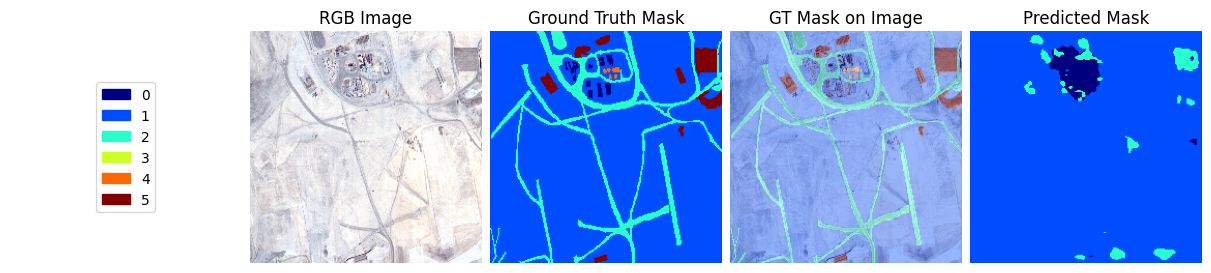

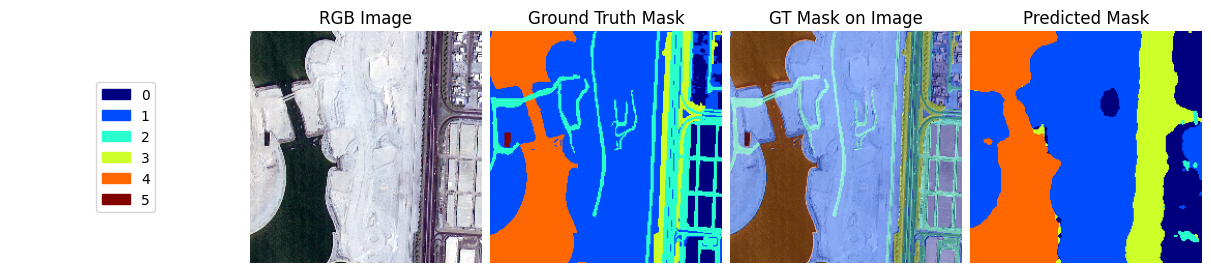

In [ ]:
model = SemanticSegmentationTask.load_from_checkpoint(
    best_ckpt_path,
    model_factory=task.hparams.model_factory,
    model_args=task.hparams.model_args,
).cuda() # Ensure the model is on the GPU

test_loader = datamodule.test_dataloader()
test_dataset = datamodule.test_dataset # Ensure test_dataset is available for plotting

with torch.no_grad():
    batch = next(iter(test_loader))
    images = batch["image"].to(model.device) # Move images to the same device as the model
    masks = batch["mask"].numpy()

    with torch.no_grad():
        outputs = model(images)

    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

for i in range(4):
    sample = {
        "image": batch["image"][i].cpu(),
        "mask": batch["mask"][i],
        "prediction": preds[i],
    }
    test_dataset.plot(sample)
    plt.show()

# 📜 Using the YAML file

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pwd

/content


In [ ]:
!terratorch fit -c /content/drive/MyDrive/AI4Good/aerial_dubai.yaml

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/cli.py:734: `SemanticSegmentationTask.configure_optimizers` will be overridden by `MyLightningCLI.configure_optimizers`.
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tr

In [ ]:
!terratorch test -c /content/drive/MyDrive/AI4Good/aerial_dubai.yaml --ckpt_path /content/demo/lightning_logs/version_3/checkpoints/epoch=4-step=70.ckpt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/cli.py:734: `SemanticSegmentationTask.configure_optimizers` will be overridden by `MyLightningCLI.configure_optimizers`.
INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tr